# Predicting Heart Disease Using Machine Learning
In this notebook, we'll try to figure out whether a patient has heart disease 
or not — just by looking at a few numbers from their medical records. 

No magic, just machine learning.

In [1]:
# Exploratory Data Analysis and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

# Models from scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Model selection
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Evaluating metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

In [2]:
df = pd.read_csv("./data/heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# About our features
age (Age of the patient in years)

sex (Male/Female)

cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])

trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))

chol (serum cholesterol in mg/dl)

fbs (if fasting blood sugar > 120 mg/dl)

restecg (resting electrocardiographic results)

-- Values: [normal, stt abnormality, lv hypertrophy]

thalach: maximum heart rate achieved

exang: exercise-induced angina (True/ False)

oldpeak: ST depression induced by exercise relative to rest

slope: the slope of the peak exercise ST segment

ca: number of major vessels (0-3) colored by fluoroscopy

thal: [normal; fixed defect; reversible defect]

In [3]:
# Exploratory Data Analysis
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1         2
63   1    3   145       233   1    0        150      0      2.3      0      0   1     1         1
37   1    2   130       250   0    1        187      0      3.5      0      0   2     1         1
41   0    1   130       204   0    0        172      0      1.4      2      0   2     1         1
56   1    1   120       236   0    1        178      0      0.8      2      0   2     1         1
                                                                                               ..
57   0    0   140       241   0    1        123      1      0.2      1      0   3     0         1
45   1    3   110       264   0    1        132      0      1.2      1      0   3     0         1
68   1    0   144       193   1    1        141      0      3.4      1      2   3     0         1
57   1    0   130       1

In [6]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


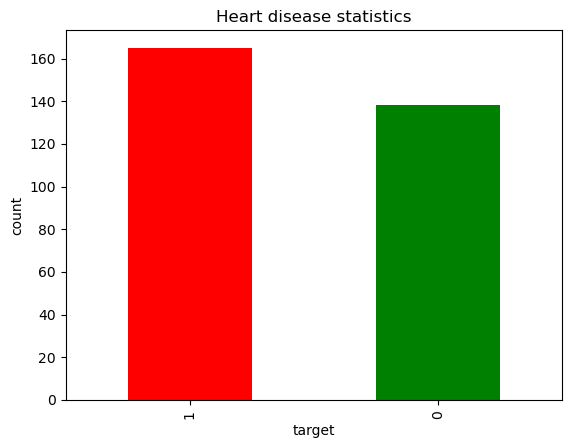

In [10]:
df["target"].value_counts().plot(kind = "bar", color = ["red", "green"], ylabel = "count", title = "Heart disease statistics");

# Finding patterns

In [11]:
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
pd.crosstab(df['target'], df['sex'])

sex,0,1
target,,
0,24,114
1,72,93


In [13]:
import sys
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




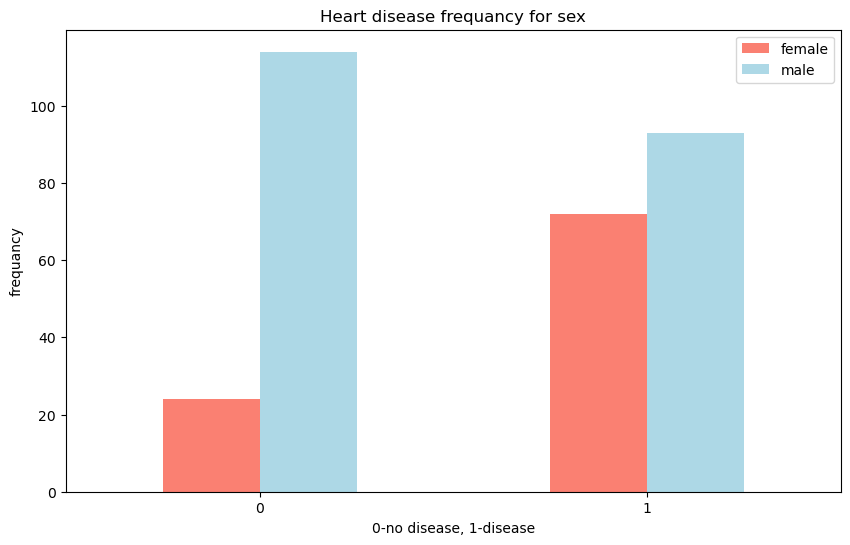

In [14]:
pd.crosstab(df['target'], df['sex']).plot(kind = "bar", figsize = (10, 6), color = ["salmon", "lightblue"])
plt.title("Heart disease frequancy for sex")
plt.xlabel("0-no disease, 1-disease")
plt.ylabel("frequancy")
plt.legend(["female", "male"])
plt.xticks(rotation = 0);

# Finding patterns 2

In [15]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [16]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [17]:
plt.style.use("default")

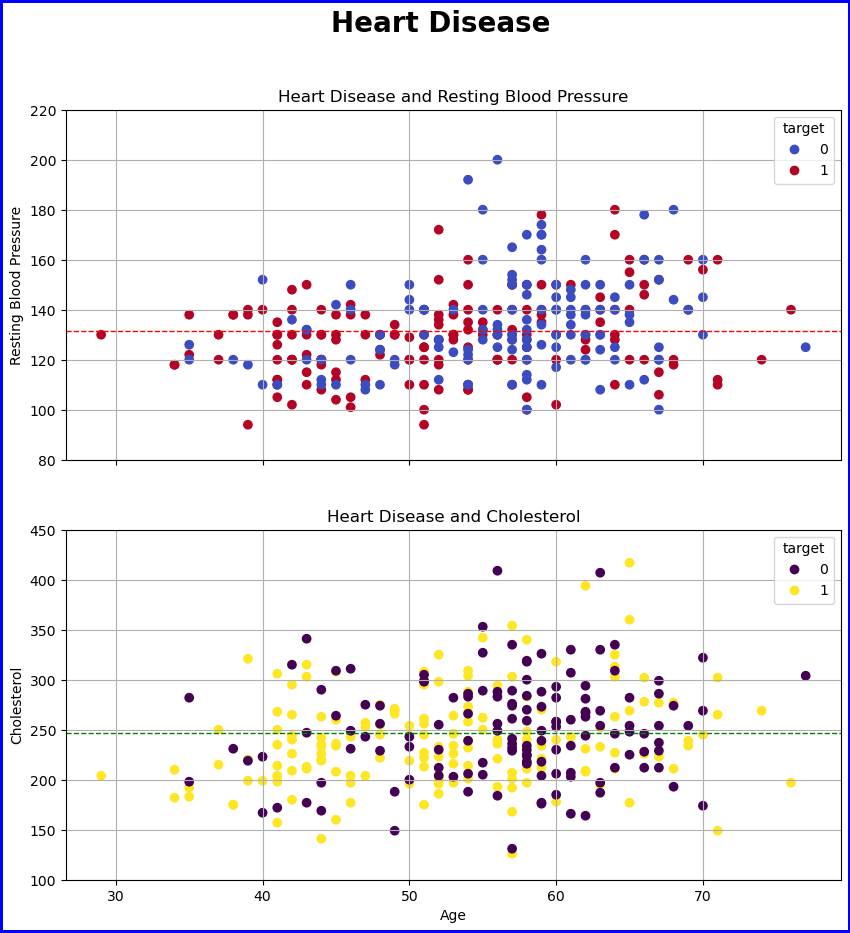

In [18]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
fig.set_size_inches(10, 10)
fig.set_edgecolor("blue")
fig.set_linewidth(3)
fig.suptitle(t = "Heart Disease", horizontalalignment = "center", fontsize = 20, fontweight = "bold")

scatter = ax1.scatter(x = df["age"], y = df["trestbps"], c = df["target"], cmap="coolwarm")
ax1.set(ylabel="Resting Blood Pressure", title = "Heart Disease and Resting Blood Pressure", ylim=(80, 220))
ax1.axhline(df['trestbps'].mean(), linestyle = "--", linewidth = "1", color = "red")
ax1.grid(visible=True, which="major")
ax1.legend(*scatter.legend_elements(), title="target")

scatter = ax2.scatter(x = df["age"], y = df["chol"], c = df["target"])
ax2.set(ylabel="Cholesterol", title = "Heart Disease and Cholesterol", xlabel="Age", ylim=(100, 450))
ax2.axhline(df['chol'].mean(), linestyle = "--", linewidth = "1", color = "green")
ax2.grid(visible=True, which="major")
ax2.legend(*scatter.legend_elements(), title="target");

# Normal distribution

[Text(0.5, 0, 'Age'), Text(0, 0.5, 'Frequency')]

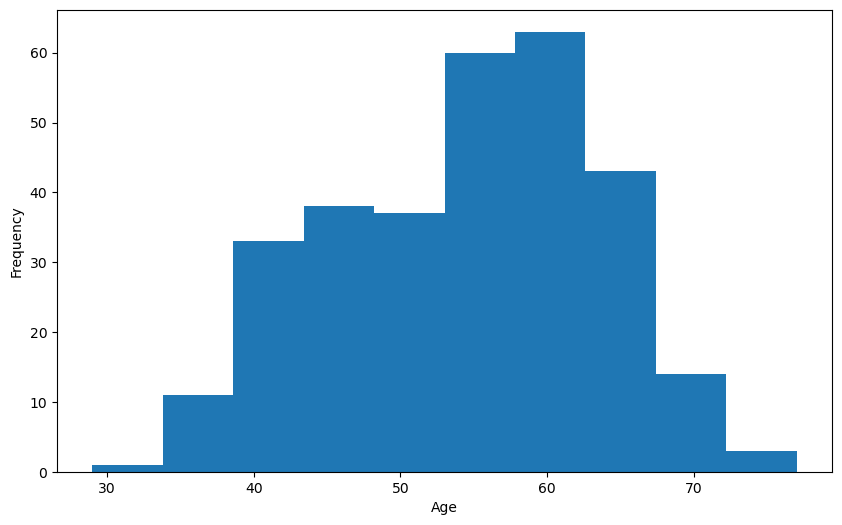

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(10, 6)

hist = ax.hist(x=df["age"])
ax.set(xlabel="Age", ylabel="Frequency")

# Correlation coefficient

In [20]:
corr_matrix = df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


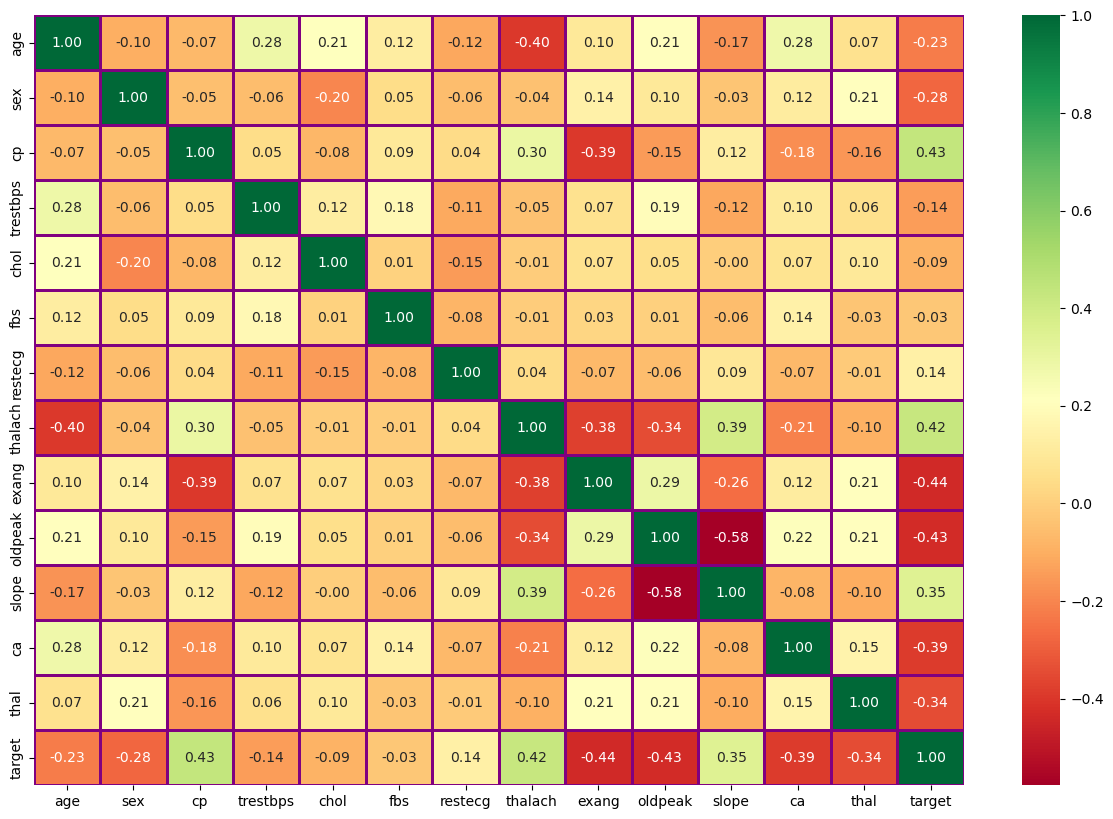

In [21]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_size_inches(15, 10)
ax = sns.heatmap(corr_matrix, cmap="RdYlGn", annot=True, linecolor="purple", linewidths="2", fmt=".2f")

 # Machine learning

In [22]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_dict = {"Logistic regression": LogisticRegression(random_state=42, max_iter=1000),
              "Random forest classifier": RandomForestClassifier(random_state=42),
              "K-nearest neighbors": KNeighborsClassifier()}

def test_models (models, X_train, X_test, y_train, y_test):
    test_result = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        test_result[name] = model.score(X_test, y_test)
    return test_result

In [23]:
test_result = test_models(model_dict, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
test_result

{'Logistic regression': 0.8852459016393442,
 'Random forest classifier': 0.8360655737704918,
 'K-nearest neighbors': 0.6885245901639344}

In [24]:
test_result_df = pd.DataFrame(data = test_result, index = ["accuracy"])

In [25]:
test_result_df

,Logistic regression,Random forest classifier,K-nearest neighbors
accuracy,0.885246,0.836066,0.688525


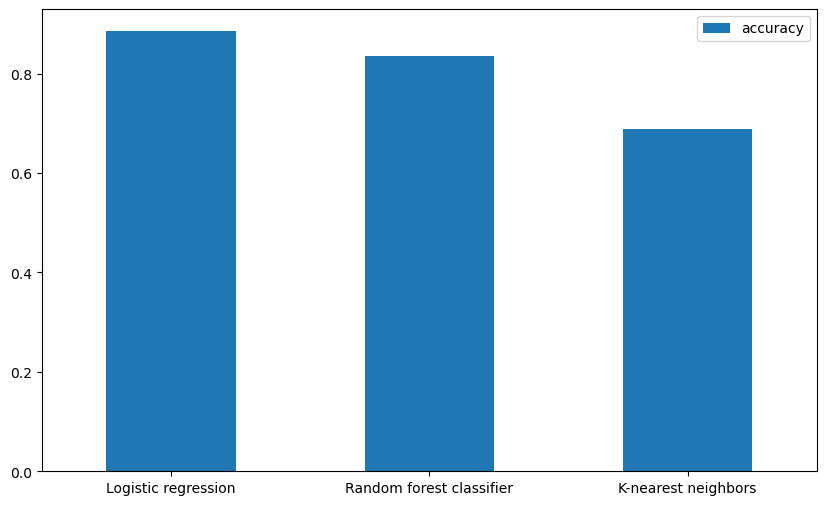

In [26]:
test_result_df.T.plot(kind= "bar", figsize = (10, 6))
plt.xticks(rotation = 0);

# Hyperparameters tuning

In [27]:
knn = KNeighborsClassifier()
n_neighbors = range(1, 21, 1)
train_scores = []
test_scores = []

for i in n_neighbors:
    knn.set_params(n_neighbors = i)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

In [28]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

In [29]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

In [30]:
max(test_scores)

0.7540983606557377

Maximum K-Nearest Neighbors score on the test data: 75.41%


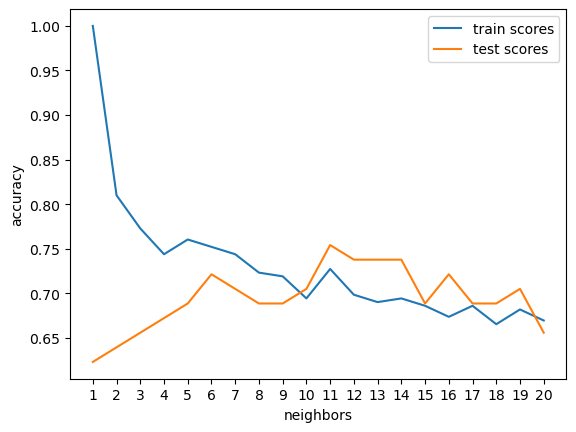

In [31]:
plt.plot(n_neighbors, train_scores, label = "train scores")
plt.plot(n_neighbors, test_scores, label = "test scores")
plt.xlabel("neighbors")
plt.ylabel("accuracy")
plt.xticks(n_neighbors)
plt.legend();

print(f"Maximum K-Nearest Neighbors score on the test data: {max(test_scores) * 100:.2f}%")

# Hyperparameters tuning using RandomizedSearchCV

In [32]:
logistic_regression_grid = {"C": np.logspace(-4, 4, 20),
                            "solver": ["lbfgs", "liblinear"]}
random_forest_grid = {"n_estimators": np.arange(100, 1000, 100),
                     "max_depth": [None, 5, 10, 20],
                     "max_features": [None, "sqrt", "log2"],
                     "min_samples_leaf": np.arange(1, 10, 3),
                     "min_samples_split": np.arange(2, 10, 2)}

In [33]:
logistic_regression_grid

{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
        4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
        2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
        1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
        5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
 'solver': ['lbfgs', 'liblinear']}

In [34]:
random_forest_grid

{'n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900]),
 'max_depth': [None, 5, 10, 20],
 'max_features': [None, 'sqrt', 'log2'],
 'min_samples_leaf': array([1, 4, 7]),
 'min_samples_split': array([2, 4, 6, 8])}

In [35]:
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(), param_distributions=logistic_regression_grid, cv=5, n_iter=40, verbose=1, random_state=42, n_jobs=2)

rs_log_reg.fit(X_train, y_train)
rs_log_reg.best_params_
rs_log_reg.score(X_test, y_test)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


0.8852459016393442

In [36]:
rs_rf = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=random_forest_grid, cv=5, n_iter=100, verbose=1, random_state=42, n_jobs=4)

rs_rf.fit(X_train, y_train)
rs_rf.best_params_
rs_rf.score(X_test, y_test)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


0.8688524590163934

In [37]:
logistic_regression_grid = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["lbfgs", "liblinear", "newton-cg"]    
}

In [38]:
gs_lr = GridSearchCV(estimator=LogisticRegression(), param_grid=logistic_regression_grid, cv=5, n_jobs=4, verbose=1)
gs_lr.fit(X_train, y_train)
gs_lr.score(X_test, y_test)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


0.8852459016393442

# Evaluating our model

In [39]:
y_probs = gs_lr.predict_proba(X_test)
y_probs

array([[0.87279281, 0.12720719],
       [0.24438104, 0.75561896],
       [0.18194449, 0.81805551],
       [0.94913682, 0.05086318],
       [0.10873317, 0.89126683],
       [0.12414506, 0.87585494],
       [0.39656891, 0.60343109],
       [0.99608744, 0.00391256],
       [0.98761472, 0.01238528],
       [0.44643133, 0.55356867],
       [0.2775678 , 0.7224322 ],
       [0.88637493, 0.11362507],
       [0.10926503, 0.89073497],
       [0.94497552, 0.05502448],
       [0.03000753, 0.96999247],
       [0.06644782, 0.93355218],
       [0.03351399, 0.96648601],
       [0.90955659, 0.09044341],
       [0.98401135, 0.01598865],
       [0.97564621, 0.02435379],
       [0.28456166, 0.71543834],
       [0.97536919, 0.02463081],
       [0.85819712, 0.14180288],
       [0.27256214, 0.72743786],
       [0.11271504, 0.88728496],
       [0.30593377, 0.69406623],
       [0.15242921, 0.84757079],
       [0.31176184, 0.68823816],
       [0.98336957, 0.01663043],
       [0.11750467, 0.88249533],
       [0.

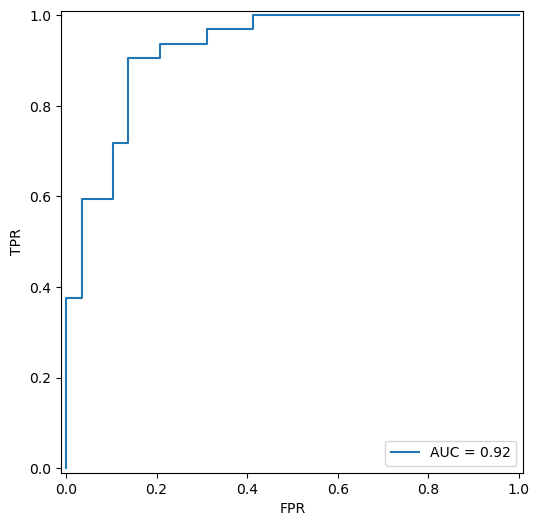

In [40]:
y_probs_positive = y_probs[:, 1]
# ["rows", "columns"]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
fig, ax = plt.subplots(figsize=(10, 6))
display.plot(ax = ax)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");

In [41]:
y_preds = gs_lr.predict(X_test)
conf_mat = confusion_matrix(y_test, y_preds)
conf_mat

array([[25,  4],
       [ 3, 29]])

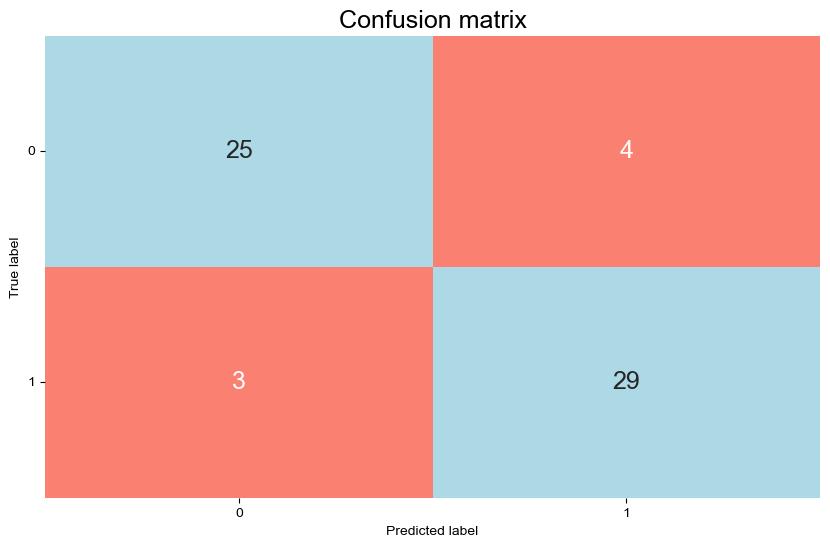

In [42]:
def plot_conf_mat(y_test, y_preds):
    fig, ax = plt.subplots(figsize = (10,6))
    sns.set(font_scale = 1.5)
    sns.heatmap(conf_mat, annot=True, cbar=False, cmap = ["salmon", "lightblue"])
    ax.tick_params(axis = "y", rotation = 0)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion matrix")

plot_conf_mat(y_test, y_preds)

In [43]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



# Cross-validation

In [44]:
gs_lr.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [45]:
lr_estimator = LogisticRegression(C=0.23357214690901212, solver='liblinear')
cv_acc = cross_val_score(lr_estimator, X, y, cv=5, n_jobs=4, verbose=1)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    0.0s finished


In [46]:
cv_mean_acc = np.mean(cv_acc)

In [47]:
cv_precision = cross_val_score(lr_estimator, X, y, cv=5, n_jobs=4, verbose=1, scoring="precision")
cv_mean_precision = cv_precision.mean()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    0.0s finished


In [48]:
cv_recall = cross_val_score(lr_estimator, X, y, cv=5, n_jobs=4, verbose=1, scoring="recall")
cv_mean_recall = np.mean(cv_recall)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    0.0s finished


In [49]:
cv_f1 = cross_val_score(lr_estimator, X, y, cv=5, n_jobs=4, verbose=1, scoring="f1")
cv_mean_f1 = np.mean(cv_recall)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:    0.0s finished


In [50]:
cv_df_lr = pd.DataFrame({"Accuracy": cv_mean_acc,
                         "Precision": cv_mean_precision,
                         "Recall": cv_mean_recall,
                         "F1": cv_mean_f1}, index=["Evaluating metrics"]) 
cv_df_lr.T

,Evaluating metrics
Accuracy,0.847978
Precision,0.821587
Recall,0.927273
F1,0.927273


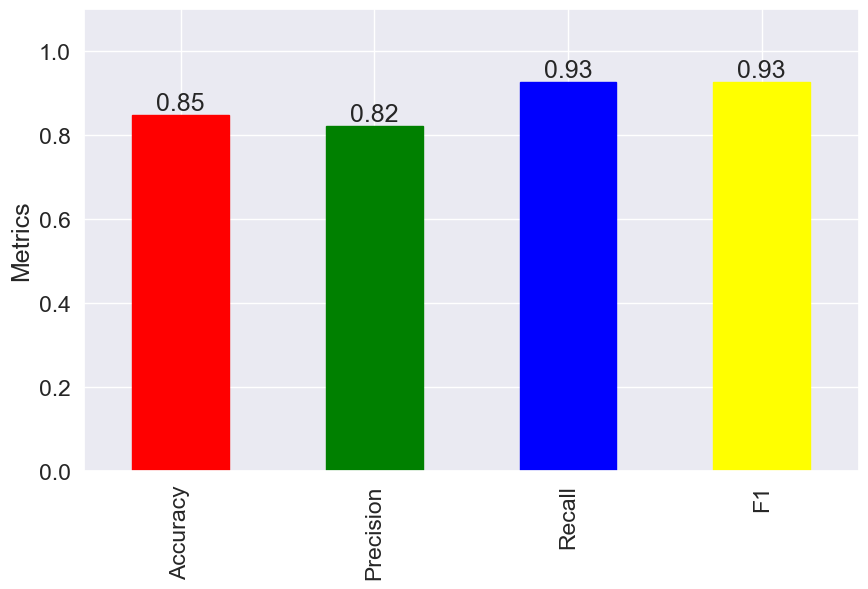

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
cv_df_lr.T.plot(ax = ax, legend=False, kind="bar")
ax.set_ylabel("Metrics")
ax.set_ylim(0, 1.1)
colors = ["red", "green", "blue", "yellow"]
for bar, color in zip(ax.patches, colors):
    bar.set_color(color)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

# Feature importance

In [52]:
gs_lr.best_params_

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [53]:
clf = LogisticRegression(C=0.23357214690901212, solver='liblinear')
clf.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.23357214690901212
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio

In [59]:
coef = clf.coef_[0]
coef

array([ 0.00369922, -0.90424098,  0.67472823, -0.0116134 , -0.00170364,
        0.04787687,  0.33490208,  0.02472938, -0.63120414, -0.57590996,
        0.47095166, -0.65165344, -0.69984217])

In [73]:
df_columns = list(df.columns)
df_columns

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [79]:
z = zip(columns, coef)
z_list = list(z)
z_dict = dict(z_list)
z_dict

{'age': np.float64(0.003699223396114675),
 'sex': np.float64(-0.9042409779785583),
 'cp': np.float64(0.6747282348693419),
 'trestbps': np.float64(-0.011613398123390507),
 'chol': np.float64(-0.0017036431858934173),
 'fbs': np.float64(0.0478768694057663),
 'restecg': np.float64(0.33490207838133623),
 'thalach': np.float64(0.024729380915946855),
 'exang': np.float64(-0.6312041363430085),
 'oldpeak': np.float64(-0.5759099636629296),
 'slope': np.float64(0.47095166489539353),
 'ca': np.float64(-0.6516534354909507),
 'thal': np.float64(-0.6998421698316164)}

In [104]:
feauture_importance_df = pd.DataFrame(z_dict, index = [0])
feauture_importance_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.003699,-0.904241,0.674728,-0.011613,-0.001704,0.047877,0.334902,0.024729,-0.631204,-0.57591,0.470952,-0.651653,-0.699842


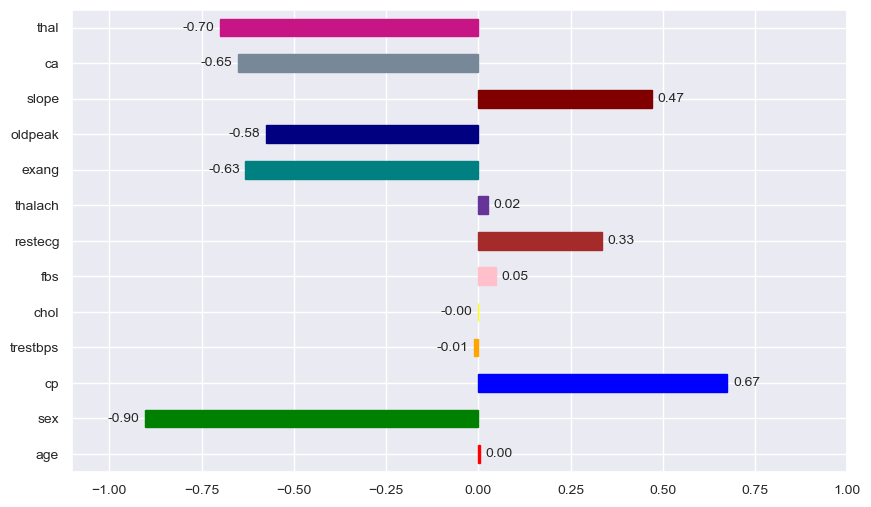

In [132]:
# feauture_importance_df.plot(kind = "bar", legend = False)
# plt.xticks(rotation = 0)

fig, ax = plt.subplots(figsize=(10, 6))
feauture_importance_df.T.plot(ax = ax, kind="barh", legend = False)

# ax.tick_params(rotation = 0)
# ax.set_ylim(-1.2, 1)
# ax.legend(fontsize = 10)
# ax.set_xlabel("Feature importance", fontsize = 10)
# ax.set_xticks([])
ax.set_xlim(-1.1,1)
# ax.xaxis.label.set_fontsize(2)
# ax.yaxis.label.set_fontsize(2)
ax.tick_params(axis="both", labelsize = 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=4, fontsize = 10)

colors = ["red", "green", "blue", "orange", "yellow", "pink", "brown", "RebeccaPurple", "teal", "#000080", "maroon", "LightSlateGray", "MediumVioletRed"]

for bar, color in zip(ax.patches, colors):
    bar.set_color(color)

In [134]:
import joblib
joblib.dump(value=clf, filename="./model/heart_disease_log_reg_model.joblib")

['heart_disease_log_reg_model.joblib']